<a href="https://colab.research.google.com/github/Kieunhungtruong/Econometrics/blob/main/pythonversion/chapter4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="display:flex;flex-direction:column;align-items:center;justify-content:center;gap:10px;">
  <h1 style="text-align:center;font-size:26px;font-weight:bold;font-family:'Nunito';color:purple;">
    Chapter 4 – Lựa chọn mô hình trong hồi quy đa biến (Regression Specification)
  </h1>
</div>

## Kết nối Google Drive và cài gói cần thiết

In [64]:
from google.colab import drive
drive.mount("/content/drive/", force_remount=True)

Mounted at /content/drive/


In [65]:
!pip install pyreadstat -q

import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
from scipy.stats import chi2, f as f_dist, jarque_bera, skew, kurtosis, norm
import pyreadstat

palette = ["#53b0ae", "#a31414", "#2b6999", "#e37000", "#b2c615", "#88837d", "#B3B3B3"]

## Đọc dữ liệu

In [66]:
df, meta = pyreadstat.read_dta(
    "/content/drive/MyDrive/econometrics/rawdata/migration_remittances_16_full.dta",
    encoding="latin1",
)
df.head()

,tinh,huyen,xa,diaban,hoso,num_migration,marital_status,HHsize,agehead,num_children0_5,...,durables_share,housing_share,others_share,healthcare_share,education_share,RedRiverDelta,Northmidlandareas,CentralCoast,Centralhighlands,MekongRiverDelta
0,1,1,4,8,14,NaN,0,2.0,63.0,0.0,...,0.000000,0.030590,0.021175,0.004854,0.044689,1.0,0.0,0.0,0.0,0.0
1,1,1,4,8,15,NaN,1,5.0,37.0,0.0,...,0.026955,0.011273,0.006304,0.000797,0.006511,1.0,0.0,0.0,0.0,0.0
2,1,1,4,8,19,NaN,1,2.0,61.0,0.0,...,0.000000,0.027630,0.013743,0.014355,0.000000,1.0,0.0,0.0,0.0,0.0
3,1,1,7,6,13,NaN,1,3.0,62.0,0.0,...,0.018952,0.022694,0.014611,0.002366,0.056978,1.0,0.0,0.0,0.0,0.0
4,1,1,7,6,14,NaN,1,5.0,62.0,0.0,...,0.000000,0.067794,0.004254,0.011658,0.002564,1.0,0.0,0.0,0.0,0.0


---
# 4.1 Bỏ sót các biến có liên quan (Omitted Variable Bias)

Khi bỏ sót biến có quan hệ với các biến trong mô hình:
- Hệ số ước lượng **bị lệch (biased)** và **không nhất quán (inconsistent)**
- Hệ số chặn bị lệch dù biến bỏ sót độc lập với các biến còn lại
- Phương sai sai số và phương sai hệ số đều ước lượng sai → khoảng tin cậy và kiểm định không chính xác

**Công thức kiểm định F so sánh hai mô hình (mô hình hạn chế vs không hạn chế):**

$$
F = \frac{\dfrac{R^2_{ur} - R^2_r}{m}}
         {\dfrac{1 - R^2_{ur}}{n - k}}
$$

với $m$ = số biến bổ sung, $k$ = số tham số mô hình không hạn chế.

## Ví dụ 1 – Chi tiêu bình quân và tiền gửi về (Bảng 4.1–4.2)

Xuất phát từ mô hình đơn biến (`remittances`), bổ sung thêm các biến kiểm soát
và dùng kiểm định F để xem mô hình ban đầu có bỏ sót biến không.

### Bước 1 – Tạo biến và định nghĩa danh sách biến

In [67]:
df["agehead2"] = df["agehead"] ** 2

xvars_full1 = ["remittances", "HHsize", "children15", "elderly60",
               "female_ratio", "genderhead", "agehead", "agehead2", "num_eduhead"]

### Bước 2 – Mô hình 1: hồi quy hạn chế (chỉ `remittances`)

In [68]:
X1_r = sm.add_constant(df["remittances"])
m1_r = sm.OLS(df["per_expenditure"], X1_r).fit()
print(m1_r.summary())
# N=9,399 | F(1,9397)=177.85 | R²=0.0186

                            OLS Regression Results                            
Dep. Variable:        per_expenditure   R-squared:                       0.019
Model:                            OLS   Adj. R-squared:                  0.018
Method:                 Least Squares   F-statistic:                     177.8
Date:                Wed, 08 Apr 2026   Prob (F-statistic):           3.31e-40
Time:                        10:41:08   Log-Likelihood:            -1.0757e+05
No. Observations:                9399   AIC:                         2.152e+05
Df Residuals:                    9397   BIC:                         2.152e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const        2.556e+04    246.728    103.613      

### Bước 3 – Mô hình 2: hồi quy không hạn chế (đầy đủ biến kiểm soát)

In [69]:
X1_ur = sm.add_constant(df[xvars_full1])
m1_ur = sm.OLS(df["per_expenditure"], X1_ur).fit()
print(m1_ur.summary())
# N=9,399 | F(9,9389)=179.64 | R²=0.1469

                            OLS Regression Results                            
Dep. Variable:        per_expenditure   R-squared:                       0.147
Model:                            OLS   Adj. R-squared:                  0.146
Method:                 Least Squares   F-statistic:                     179.6
Date:                Wed, 08 Apr 2026   Prob (F-statistic):          8.76e-316
Time:                        10:41:08   Log-Likelihood:            -1.0692e+05
No. Observations:                9399   AIC:                         2.139e+05
Df Residuals:                    9389   BIC:                         2.139e+05
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const         1.256e+04   2843.516      4.419   

### Bước 4 – Kiểm định F thủ công

In [70]:
R2_r  = m1_r.rsquared   # 0.0186
R2_ur = m1_ur.rsquared  # 0.1469
m_add = 8               # số biến bổ sung
n1    = int(m1_ur.nobs)
k1    = len(xvars_full1) + 1   # 10 tham số

F1 = ((R2_ur - R2_r) / m_add) / ((1 - R2_ur) / (n1 - k1))
p1 = 1 - f_dist.cdf(F1, dfn=m_add, dfd=n1 - k1)

print(f"R² hạn chế       = {R2_r:.4f}")
print(f"R² không hạn chế = {R2_ur:.4f}")
print(f"F statistic      = {F1:.2f}")
print(f"p-value          = {p1:.4f}")
# F ≈ 176.55, p ≈ 0.000 → bác bỏ H₀: mô hình ban đầu bỏ sót biến

R² hạn chế       = 0.0186
R² không hạn chế = 0.1469
F statistic      = 176.55
p-value          = 0.0000


## Ví dụ 3 – Mức lương người lao động (Bảng 4.3–4.6)

Kiểm tra liệu tác động của kinh nghiệm có phi tuyến và có sự khác biệt vùng không.

### Bước 1 – Đọc dữ liệu và tạo biến

In [71]:
df_wage, _ = pyreadstat.read_dta(
    "/content/drive/MyDrive/econometrics/rawdata/wage2020.dta",
    encoding="latin1",
)

df_wage["yearsofexperience2"] = df_wage["yearsofexperience"] ** 2
df_wage["experienceXgender"]  = df_wage["yearsofexperience"] * df_wage["gender"]

xvars_r3  = ["urban", "gender", "yearsofedu", "yearsofexperience"]
xvars_ur3 = ["urban", "gender", "yearsofedu", "yearsofexperience",
             "yearsofexperience2", "experienceXgender",
             "RedRiverDelta", "Northmidlandareas", "CentralCoast",
             "Centralhighlands", "MekongRiverDelta"]

### Bước 2 – Mô hình 1: hạn chế

In [72]:
X3_r = sm.add_constant(df_wage[xvars_r3])
m3_r = sm.OLS(df_wage["wage"], X3_r).fit()
print(m3_r.summary())
# N=10,118 | F(4,10113)=633.02 | R²=0.2002

                            OLS Regression Results                            
Dep. Variable:                   wage   R-squared:                       0.200
Model:                            OLS   Adj. R-squared:                  0.200
Method:                 Least Squares   F-statistic:                     633.0
Date:                Wed, 08 Apr 2026   Prob (F-statistic):               0.00
Time:                        10:41:08   Log-Likelihood:            -1.2341e+05
No. Observations:               10118   AIC:                         2.468e+05
Df Residuals:                   10113   BIC:                         2.469e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const              1.096e+04   2148.70

### Bước 3 – Mô hình 2: không hạn chế

In [73]:
X3_ur = sm.add_constant(df_wage[xvars_ur3])
m3_ur = sm.OLS(df_wage["wage"], X3_ur).fit()
print(m3_ur.summary())
# N=10,118 | F(11,10106)=384.32 | R²=0.2949

                            OLS Regression Results                            
Dep. Variable:                   wage   R-squared:                       0.295
Model:                            OLS   Adj. R-squared:                  0.294
Method:                 Least Squares   F-statistic:                     384.3
Date:                Wed, 08 Apr 2026   Prob (F-statistic):               0.00
Time:                        10:41:08   Log-Likelihood:            -1.2278e+05
No. Observations:               10118   AIC:                         2.456e+05
Df Residuals:                   10106   BIC:                         2.457e+05
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const               1.908e+04   2662

### Bước 4 – Kiểm định F

In [74]:
R2_r3  = m3_r.rsquared
R2_ur3 = m3_ur.rsquared
m_add3 = 7
n3     = int(m3_ur.nobs)
k3     = len(xvars_ur3) + 1

F3 = ((R2_ur3 - R2_r3) / m_add3) / ((1 - R2_ur3) / (n3 - k3))
p3 = 1 - f_dist.cdf(F3, dfn=m_add3, dfd=n3 - k3)
print(f"F = {F3:.2f}, p = {p3:.4f}")
# F ≈ 193.91 → bác bỏ H₀

F = 193.91, p = 0.0000


---
# 4.2 Kiểm định đặc tả mô hình

## Kiểm định RESET (Ramsey’s Regression Specification Error Test)

**Ý tưởng:** Nếu mô hình đúng dạng hàm, các lũy thừa của $\hat{y}$ không có ý nghĩa khi thêm vào mô hình.

**Quy trình thủ công (theo log Stata):**
1. Hồi quy mô hình gốc → lấy $\hat{y}$
2. Tạo $\hat{y}^2, \hat{y}^3, \hat{y}^4$
3. Hồi quy mở rộng gồm biến gốc + $\hat{y}^2, \hat{y}^3$ → kiểm định F
4. Hồi quy mở rộng gồm biến gốc + $\hat{y}^2, \hat{y}^3, \hat{y}^4$ → kiểm định F
5. Kiểm định RESET tự động bằng `ovtest`

> **Lưu ý:** Stata dùng `wage_million = wage/1000` để tránh overflow khi tính $\hat{y}^3, \hat{y}^4$.

### Bước 1 – Chuẩn hóa đơn vị và hồi quy mô hình gốc

In [75]:
df_wage["wage_million"] = df_wage["wage"] / 1000

X_reset = sm.add_constant(df_wage[xvars_r3])
m_reset = sm.OLS(df_wage["wage_million"], X_reset).fit()
print(m_reset.summary())
# Hệ số giống wage nhưng scale nhỏ hơn 1000 lần
# N=10,118 | F(4,10113)=633.02 | R²=0.2002

                            OLS Regression Results                            
Dep. Variable:           wage_million   R-squared:                       0.200
Model:                            OLS   Adj. R-squared:                  0.200
Method:                 Least Squares   F-statistic:                     633.0
Date:                Wed, 08 Apr 2026   Prob (F-statistic):               0.00
Time:                        10:41:09   Log-Likelihood:                -53521.
No. Observations:               10118   AIC:                         1.071e+05
Df Residuals:                   10113   BIC:                         1.071e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                10.9602      2.14

### Bước 2 – Tạo $\hat{y}^2, \hat{y}^3, \hat{y}^4$

In [76]:
df_wage["yhat_million"]  = m_reset.fittedvalues
df_wage["yhat2_million"] = df_wage["yhat_million"] ** 2
df_wage["yhat3_million"] = df_wage["yhat_million"] ** 3
df_wage["yhat4_million"] = df_wage["yhat_million"] ** 4

### Bước 3 – Hồi quy mở rộng với $\hat{y}^2, \hat{y}^3$

In [77]:
X_ext23 = sm.add_constant(df_wage[xvars_r3 + ["yhat2_million", "yhat3_million"]])
m_ext23 = sm.OLS(df_wage["wage_million"], X_ext23).fit()
print(m_ext23.summary())
# F(6,10111)=505.48 | R²=0.2307

                            OLS Regression Results                            
Dep. Variable:           wage_million   R-squared:                       0.231
Model:                            OLS   Adj. R-squared:                  0.230
Method:                 Least Squares   F-statistic:                     505.5
Date:                Wed, 08 Apr 2026   Prob (F-statistic):               0.00
Time:                        10:41:09   Log-Likelihood:                -53325.
No. Observations:               10118   AIC:                         1.067e+05
Df Residuals:                   10111   BIC:                         1.067e+05
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                28.6288      3.20

### Bước 4 – Kiểm định F cho $\hat{y}^2, \hat{y}^3$



In [78]:
RSS_base = m_reset.ssr
RSS_23   = m_ext23.ssr
q23      = 2
dfd23    = m_ext23.df_resid

F_23 = ((RSS_base - RSS_23) / q23) / (RSS_23 / dfd23)
p_23 = 1 - f_dist.cdf(F_23, dfn=q23, dfd=dfd23)
print(f"F({q23}, {int(dfd23)}) = {F_23:.2f},  Prob > F = {p_23:.4f}")
# F ≈ 200.46, p = 0.000 → bác bỏ H₀

F(2, 10111) = 200.46,  Prob > F = 0.0000


### Bước 5 – Hồi quy mở rộng thêm $\hat{y}^4$

In [79]:
X_ext234 = sm.add_constant(df_wage[xvars_r3 + ["yhat2_million", "yhat3_million", "yhat4_million"]])
m_ext234 = sm.OLS(df_wage["wage_million"], X_ext234).fit()
print(m_ext234.summary())
# F(7,10110)=433.32 | R²=0.2308

                            OLS Regression Results                            
Dep. Variable:           wage_million   R-squared:                       0.231
Model:                            OLS   Adj. R-squared:                  0.230
Method:                 Least Squares   F-statistic:                     433.3
Date:                Wed, 08 Apr 2026   Prob (F-statistic):               0.00
Time:                        10:41:09   Log-Likelihood:                -53324.
No. Observations:               10118   AIC:                         1.067e+05
Df Residuals:                   10110   BIC:                         1.067e+05
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                28.7387      3.21

In [80]:
RSS_234 = m_ext234.ssr
q234    = 3
dfd234  = m_ext234.df_resid

F_234 = ((RSS_base - RSS_234) / q234) / (RSS_234 / dfd234)
p_234 = 1 - f_dist.cdf(F_234, dfn=q234, dfd=dfd234)
print(f"F({q234}, {int(dfd234)}) = {F_234:.2f},  Prob > F = {p_234:.4f}")
# F ≈ 133.79, p = 0.000

F(3, 10110) = 133.79,  Prob > F = 0.0000


### Bước 6 – Kiểm định RESET tự động (`ovtest`)

In [81]:
from statsmodels.stats.diagnostic import linear_reset

reset_test = linear_reset(m_reset, power=4, use_f=True)
print(f"Ramsey RESET F(3, {int(m_reset.df_resid - 3)}) = {reset_test.fvalue:.2f}")
print(f"Prob > F = {reset_test.pvalue:.4f}")
# F ≈ 133.79, Prob > F = 0.0000
# → Bác bỏ H₀: mô hình có dạng hàm không phù hợp

Ramsey RESET F(3, 10110) = 133.79
Prob > F = 0.0000


---
## Kiểm định LM (Lagrange Multiplier)

**Quy trình:**
1. Hồi quy mô hình hạn chế (xvars_r3) → lấy phần dư $\\hat{r}$
2. Hồi quy $\\hat{r}$ theo tất cả biến của mô hình không hạn chế (xvars_ur3)
3. Thống kê $LM = n \times R^2 \sim \chi^2(m)$ với $m$ = số biến thêm vào

### Bước 1 – Hồi quy mô hình hạn chế (dùng `wage` gốc)

In [82]:
X_lm_r = sm.add_constant(df_wage[xvars_r3])
m_lm_r = sm.OLS(df_wage["wage"], X_lm_r).fit()
print(m_lm_r.summary())
# N=10,118 | R²=0.2002

                            OLS Regression Results                            
Dep. Variable:                   wage   R-squared:                       0.200
Model:                            OLS   Adj. R-squared:                  0.200
Method:                 Least Squares   F-statistic:                     633.0
Date:                Wed, 08 Apr 2026   Prob (F-statistic):               0.00
Time:                        10:41:09   Log-Likelihood:            -1.2341e+05
No. Observations:               10118   AIC:                         2.468e+05
Df Residuals:                   10113   BIC:                         2.469e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const              1.096e+04   2148.70

### Bước 2 – Hồi quy phần dư theo mô hình không hạn chế

In [83]:
r_lm     = m_lm_r.resid
X_lm_aux = sm.add_constant(df_wage[xvars_ur3])
m_lm_aux = sm.OLS(r_lm, X_lm_aux).fit()
print(m_lm_aux.summary())
# R² ≈ 0.1184

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.118
Model:                            OLS   Adj. R-squared:                  0.117
Method:                 Least Squares   F-statistic:                     123.4
Date:                Wed, 08 Apr 2026   Prob (F-statistic):          1.65e-266
Time:                        10:41:09   Log-Likelihood:            -1.2278e+05
No. Observations:               10118   AIC:                         2.456e+05
Df Residuals:                   10106   BIC:                         2.457e+05
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const               8119.1570   2662

### Bước 3 – Tính thống kê LM và p-value

In [84]:
n_lm = int(m_lm_aux.nobs)
LM   = n_lm * m_lm_aux.rsquared
p_lm = 1 - chi2.cdf(LM, df=7)

print(f"LM = n × R² = {n_lm} × {m_lm_aux.rsquared:.4f} = {LM:.2f}")
print(f"p-value = {p_lm:.4e}")
# LM ≈ 1198, p ≈ 0 → bác bỏ H₀

LM = n × R² = 10118 × 0.1184 = 1198.06
p-value = 0.0000e+00


---
## Loại bỏ biến không liên quan (ngưỡng mức ý nghĩa 5%)

### Ví dụ 2 – Tỉ lệ chi tiêu thực phẩm (Bảng 4.7)

### Bước 1 – Mô hình đầy đủ (quá mức)

In [85]:
df["agehead2"] = df["agehead"] ** 2
df["HHsize2"]  = df["HHsize"]  ** 2

xvar_full = ["ln_expenditure", "agehead", "agehead2", "primary", "secondary",
             "high_school", "higher_education", "HHsize", "HHsize2",
             "dependency_ratio", "domestic_remittances", "overseas_remittances",
             "urban", "RedRiverDelta", "Northmidlandareas", "MekongRiverDelta",
             "Centralhighlands", "CentralCoast"]

df_fs  = df.dropna(subset=["food_share"] + xvar_full).copy()
X_full = sm.add_constant(df_fs[xvar_full])
m_full = sm.OLS(df_fs["food_share"], X_full).fit()
print(m_full.summary())
# N=8,381 | F(18,8362)=1040.95 | R²=0.6914

                            OLS Regression Results                            
Dep. Variable:             food_share   R-squared:                       0.691
Model:                            OLS   Adj. R-squared:                  0.691
Method:                 Least Squares   F-statistic:                     1041.
Date:                Wed, 08 Apr 2026   Prob (F-statistic):               0.00
Time:                        10:41:10   Log-Likelihood:                 13344.
No. Observations:                8381   AIC:                        -2.665e+04
Df Residuals:                    8362   BIC:                        -2.652e+04
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    0.8971 

### Bước 2 – Loại biến có p > 0.05 → mô hình tiết kiệm

In [86]:
# Loại: primary, secondary, high_school, higher_education,
#        domestic_remittances, overseas_remittances, RedRiverDelta, CentralCoast
xvar_red = ["ln_expenditure", "agehead", "agehead2", "HHsize", "HHsize2",
            "dependency_ratio", "urban", "Northmidlandareas",
            "MekongRiverDelta", "Centralhighlands"]

X_red = sm.add_constant(df_fs[xvar_red])
m_red = sm.OLS(df_fs["food_share"], X_red).fit()
print(m_red.summary())
# N=8,381 | F(10,8370)=1873.75 | R²=0.6912
# → R² gần như không đổi, mô hình đơn giản hơn

                            OLS Regression Results                            
Dep. Variable:             food_share   R-squared:                       0.691
Model:                            OLS   Adj. R-squared:                  0.691
Method:                 Least Squares   F-statistic:                     1874.
Date:                Wed, 08 Apr 2026   Prob (F-statistic):               0.00
Time:                        10:41:10   Log-Likelihood:                 13341.
No. Observations:                8381   AIC:                        -2.666e+04
Df Residuals:                    8370   BIC:                        -2.658e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 0.8961      0.01

### Ví dụ 3 – Kiểm tra đa cộng tuyến giữa kinh nghiệm và tuổi (Bảng 4.8)

In [87]:
m_age = sm.OLS(df_wage["yearsofexperience"],
               sm.add_constant(df_wage["age"])).fit()
print(m_age.summary())
# Beta ≈ 0.964 → yearsofexperience và age gần như collinear

                            OLS Regression Results                            
Dep. Variable:      yearsofexperience   R-squared:                       0.930
Model:                            OLS   Adj. R-squared:                  0.930
Method:                 Least Squares   F-statistic:                 1.343e+05
Date:                Wed, 08 Apr 2026   Prob (F-statistic):               0.00
Time:                        10:41:10   Log-Likelihood:                -26617.
No. Observations:               10118   AIC:                         5.324e+04
Df Residuals:                   10116   BIC:                         5.325e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -17.4447      0.114   -153.393      0.0

---
# 4.3 Mô hình sử dụng dạng hàm không phù hợp

Kiểm định **PE (Davidson–MacKinnon)** chọn giữa dạng **linear** và **log-linear**:

$$
T = \frac{n}{2} \ln \left( \frac{RSS_1}{RSS_2} \right) \sim \chi^2_{(1)}
$$

**Quy trình 5 bước (Ví dụ 1 – chi tiêu):**
1. Hồi quy log-linear để kiểm tra trước dạng hàm
2. Tính geometric mean của Y từ toàn bộ mẫu **(kể cả obs có remittances = 0)**
3. Tạo `Y_g = Y / Gmean` và `lnY_g = ln(Y_g)`
4. Hồi quy linear: `Y_g ~ X` → lưu RSS₁; hồi quy log: `lnY_g ~ lnX` → lưu RSS₂
5. Tính thống kê T và p-value

### Bước 1 – Hồi quy log-linear tham khảo (Bảng 4.10)

In [88]:
# Lọc obs có remittances > 0 để lấy ln_remittances
df["ln_per_expenditure"] = np.log(df["per_expenditure"])
df["ln_remittances"]     = np.where(df["remittances"] > 0, np.log(df["remittances"]), np.nan)

df_logex = df.dropna(subset=["ln_remittances"]).copy()
X_logex  = sm.add_constant(df_logex[["ln_remittances", "HHsize", "children15",
                                      "elderly60", "female_ratio", "genderhead",
                                      "agehead", "agehead2", "num_eduhead"]])
m_logex  = sm.OLS(df_logex["ln_per_expenditure"], X_logex).fit()
print(m_logex.summary())
# N=7,953 | F(9,7943)=366.24 | R²=0.2933

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


                            OLS Regression Results                            
Dep. Variable:     ln_per_expenditure   R-squared:                       0.293
Model:                            OLS   Adj. R-squared:                  0.292
Method:                 Least Squares   F-statistic:                     366.2
Date:                Wed, 08 Apr 2026   Prob (F-statistic):               0.00
Time:                        10:41:10   Log-Likelihood:                -6062.4
No. Observations:                7953   AIC:                         1.214e+04
Df Residuals:                    7943   BIC:                         1.221e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              8.8838      0.079    113.

### Bước 2 – Tính geometric mean từ toàn bộ mẫu (9,399 obs)

In [89]:
# Stata: sum ln_per_expenditure trên TẤT CẢ 9,399 obs (kể cả remittances=0)
mean_ln = df["ln_per_expenditure"].mean()   # = 9.98008
gmean   = np.exp(mean_ln)
print(f"Mean of ln_per_expenditure = {mean_ln:.5f}")
print(f"Geometric mean             = {gmean:,.2f}")  # ≈ 21,592

Mean of ln_per_expenditure = 9.98008
Geometric mean             = 21,592.03


### Bước 3 – Tạo biến chuẩn hóa

In [90]:
df["per_expenditure_g"]   = df["per_expenditure"] / gmean
df["lnper_expenditure_g"] = np.log(df["per_expenditure_g"])

### Bước 4a – Hồi quy linear: `per_expenditure_g ~ X` → RSS₁

In [91]:
X_lin_pe = sm.add_constant(df[xvars_full1])
m_lin_pe = sm.OLS(df["per_expenditure_g"], X_lin_pe).fit()
print(m_lin_pe.summary())
RSS1_pe = m_lin_pe.ssr
print(f"\nRSS₁ (linear) = {RSS1_pe:.4f}")   # ≈ 8962.72
# N=9,399 (toàn bộ mẫu kể cả remittances=0)

                            OLS Regression Results                            
Dep. Variable:      per_expenditure_g   R-squared:                       0.147
Model:                            OLS   Adj. R-squared:                  0.146
Method:                 Least Squares   F-statistic:                     179.6
Date:                Wed, 08 Apr 2026   Prob (F-statistic):          8.76e-316
Time:                        10:41:10   Log-Likelihood:                -13113.
No. Observations:                9399   AIC:                         2.625e+04
Df Residuals:                    9389   BIC:                         2.632e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            0.5819      0.132      4.419   

### Bước 4b – Hồi quy log: `lnper_expenditure_g ~ lnX` → RSS₂

In [92]:
xvars_log = ["ln_remittances", "HHsize", "children15", "elderly60",
             "female_ratio", "genderhead", "agehead", "agehead2", "num_eduhead"]

# Chỉ obs có ln_remittances (7,953 obs)
df_log2  = df.dropna(subset=["ln_remittances"]).copy()
X_log_pe = sm.add_constant(df_log2[xvars_log])
m_log_pe = sm.OLS(df_log2["lnper_expenditure_g"], X_log_pe).fit()
print(m_log_pe.summary())
RSS2_pe = m_log_pe.ssr
print(f"\nRSS₂ (log) = {RSS2_pe:.4f}")   # ≈ 2138.76
# N=7,953

                             OLS Regression Results                            
Dep. Variable:     lnper_expenditure_g   R-squared:                       0.293
Model:                             OLS   Adj. R-squared:                  0.292
Method:                  Least Squares   F-statistic:                     366.2
Date:                 Wed, 08 Apr 2026   Prob (F-statistic):               0.00
Time:                         10:41:11   Log-Likelihood:                -6062.4
No. Observations:                 7953   AIC:                         1.214e+04
Df Residuals:                     7943   BIC:                         1.221e+04
Df Model:                            9                                         
Covariance Type:             nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -1.0963      0.0

### Bước 5 – Tính thống kê T và kết luận

In [93]:
# n dùng trong công thức = N của mô hình log (7,953)
N_pe  = m_log_pe.nobs
T_pe  = (N_pe / 2) * np.log(RSS1_pe / RSS2_pe)
p_pe  = 1 - chi2.cdf(T_pe, df=1)

print(f"N     = {int(N_pe)}")
print(f"RSS₁  = {RSS1_pe:.4f}")
print(f"RSS₂  = {RSS2_pe:.4f}")
print(f"T     = (N/2) × ln(RSS₁/RSS₂) = {T_pe:.2f}")
print(f"p-value = {p_pe:.4e}")
# T ≈ 5697.72, p ≈ 0 → bác bỏ H₀ → dạng log phù hợp hơn linear

N     = 7953
RSS₁  = 8962.7166
RSS₂  = 2138.7598
T     = (N/2) × ln(RSS₁/RSS₂) = 5697.72
p-value = 0.0000e+00


## Ví dụ 3 – Kiểm định dạng hàm cho mô hình lương (Bảng 4.11)

Tương tự 5 bước trên nhưng dùng `wage_million = wage/1000` để tránh overflow.

### Bước 1 – Hồi quy log-linear tham khảo

In [94]:
df_wage["ln_wage"] = np.log(df_wage["wage"])

X_log_w = sm.add_constant(df_wage[xvars_ur3])
m_log_w = sm.OLS(df_wage["ln_wage"], X_log_w).fit()
print(m_log_w.summary())
# N=10,118 | R²=0.3197

                            OLS Regression Results                            
Dep. Variable:                ln_wage   R-squared:                       0.320
Model:                            OLS   Adj. R-squared:                  0.319
Method:                 Least Squares   F-statistic:                     431.8
Date:                Wed, 08 Apr 2026   Prob (F-statistic):               0.00
Time:                        10:41:11   Log-Likelihood:                -10798.
No. Observations:               10118   AIC:                         2.162e+04
Df Residuals:                   10106   BIC:                         2.171e+04
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  9.9988      0

### Bước 2 – Tính geometric mean của wage

In [95]:
mean_lnw = df_wage["ln_wage"].mean()   # = 10.94526
gmean_w  = np.exp(mean_lnw)
print(f"Mean of ln_wage   = {mean_lnw:.5f}")
print(f"Geometric mean    = {gmean_w:,.2f}")  # ≈ 56,685

Mean of ln_wage   = 10.94526
Geometric mean    = 56,684.96


### Bước 3 – Tạo biến chuẩn hóa

In [96]:
df_wage["wage_g"]    = df_wage["wage"] / gmean_w
df_wage["lnwage_g"]  = np.log(df_wage["wage_g"])

### Bước 4a – Hồi quy linear: `wage_g ~ X` → RSS₁

In [97]:
X_lin_w = sm.add_constant(df_wage[xvars_ur3])
m_lin_w = sm.OLS(df_wage["wage_g"], X_lin_w).fit()
print(m_lin_w.summary())
RSS1_w = m_lin_w.ssr
print(f"\nRSS₁ (linear) = {RSS1_w:.4f}")  # ≈ 6390.48

                            OLS Regression Results                            
Dep. Variable:                 wage_g   R-squared:                       0.295
Model:                            OLS   Adj. R-squared:                  0.294
Method:                 Least Squares   F-statistic:                     384.3
Date:                Wed, 08 Apr 2026   Prob (F-statistic):               0.00
Time:                        10:41:11   Log-Likelihood:                -12032.
No. Observations:               10118   AIC:                         2.409e+04
Df Residuals:                   10106   BIC:                         2.418e+04
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  0.3366      0

### Bước 4b – Hồi quy log: `lnwage_g ~ X` → RSS₂

In [98]:
X_log_w2 = sm.add_constant(df_wage[xvars_ur3])
m_log_w2 = sm.OLS(df_wage["lnwage_g"], X_log_w2).fit()
print(m_log_w2.summary())
RSS2_w = m_log_w2.ssr
print(f"\nRSS₂ (log) = {RSS2_w:.4f}")  # ≈ 5006.82

                            OLS Regression Results                            
Dep. Variable:               lnwage_g   R-squared:                       0.320
Model:                            OLS   Adj. R-squared:                  0.319
Method:                 Least Squares   F-statistic:                     431.8
Date:                Wed, 08 Apr 2026   Prob (F-statistic):               0.00
Time:                        10:41:11   Log-Likelihood:                -10798.
No. Observations:               10118   AIC:                         2.162e+04
Df Residuals:                   10106   BIC:                         2.171e+04
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 -0.9464      0

### Bước 5 – Thống kê T và kết luận

In [99]:
N_w  = m_log_w2.nobs
T_w  = (N_w / 2) * np.log(RSS1_w / RSS2_w)
p_w  = 1 - chi2.cdf(T_w, df=1)
print(f"T = {T_w:.4f},  p-value = {p_w:.4e}")
# T ≈ 1234.44, p ≈ 2e-270 → bác bỏ H₀ → dạng log phù hợp hơn

T = 1234.4417,  p-value = 0.0000e+00


---
# 4.5 Quan sát có giá trị bất thường (Outliers)

## Ví dụ 4 – Tai nạn giao thông và lưu lượng xe (Bảng 4.12–4.14)

### Bước 1 – Đọc dữ liệu và hồi quy toàn bộ mẫu (Bảng 4.12)

In [100]:
df_acc, _ = pyreadstat.read_dta(
    "/content/drive/MyDrive/econometrics/rawdata/rotations_accidents2022.dta",
    encoding="latin1",
)
df_acc["idprovince"] = range(1, len(df_acc) + 1)

X_acc = sm.add_constant(df_acc["rotations"])
m_acc = sm.OLS(df_acc["traffic_accidents"], X_acc).fit()
print(m_acc.summary())
df_acc["resid"] = m_acc.resid
# N=63 | F(1,61)=126.88 | R²=0.6753

                            OLS Regression Results                            
Dep. Variable:      traffic_accidents   R-squared:                       0.675
Model:                            OLS   Adj. R-squared:                  0.670
Method:                 Least Squares   F-statistic:                     126.9
Date:                Wed, 08 Apr 2026   Prob (F-statistic):           1.55e-16
Time:                        10:41:11   Log-Likelihood:                -407.07
No. Observations:                  63   AIC:                             818.1
Df Residuals:                      61   BIC:                             822.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         29.4514     24.000      1.227      0.2

### Bước 2 – Vẽ bình phương phần dư theo tỉnh (Hình 4.1)

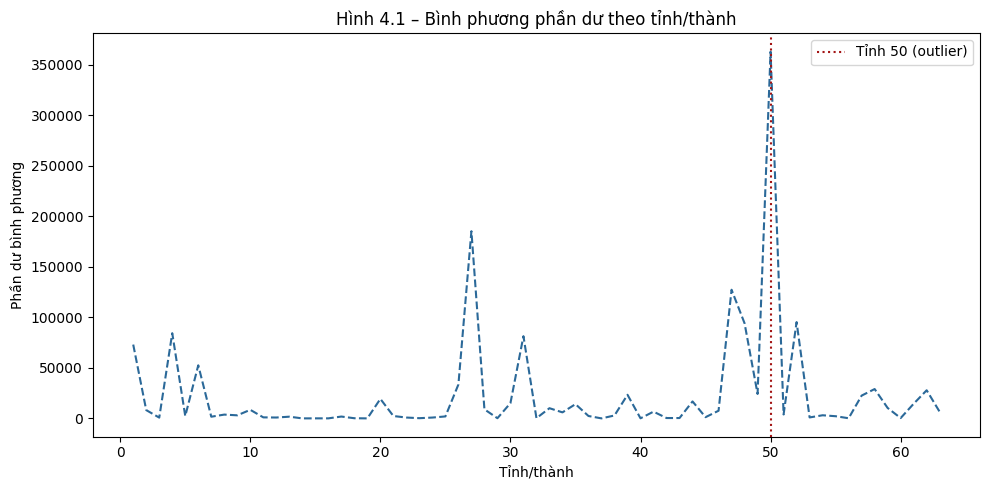

In [101]:
df_acc["resid_sq"] = df_acc["resid"] ** 2

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df_acc["idprovince"], df_acc["resid_sq"],
        color=palette[2], linestyle="--", linewidth=1.5)
ax.axvline(x=50, color=palette[1], linestyle=":", linewidth=1.5, label="Tỉnh 50 (outlier)")
ax.set_xlabel("Tỉnh/thành")
ax.set_ylabel("Phần dư bình phương")
ax.set_title("Hình 4.1 – Bình phương phần dư theo tỉnh/thành")
ax.legend()
plt.tight_layout()

### Bước 3 – Xóa outlier (tỉnh 50) và hồi quy lại (Bảng 4.13)

In [102]:
df_acc2 = df_acc[df_acc["idprovince"] != 50].copy()
m_acc2  = sm.OLS(df_acc2["traffic_accidents"],
                 sm.add_constant(df_acc2["rotations"])).fit()
print(m_acc2.summary())
# N=62 | F(1,60)=34.15 | R²=0.3627
# → Hệ số rotations giảm từ 0.086 xuống 0.046 khi bỏ outlier

                            OLS Regression Results                            
Dep. Variable:      traffic_accidents   R-squared:                       0.363
Model:                            OLS   Adj. R-squared:                  0.352
Method:                 Least Squares   F-statistic:                     34.15
Date:                Wed, 08 Apr 2026   Prob (F-statistic):           2.24e-07
Time:                        10:41:13   Log-Likelihood:                -380.89
No. Observations:                  62   AIC:                             765.8
Df Residuals:                      60   BIC:                             770.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         82.1131     18.848      4.357      0.0

### Bước 4 – Robust Regression (Bảng 4.14)

In [103]:
from statsmodels.robust.robust_linear_model import RLM
from statsmodels.robust.norms import HuberT, TukeyBiweight

# bước 1 Huber
m_huber = RLM(df_acc["traffic_accidents"], X_acc, M=HuberT()).fit()

# bước 2 Biweight
m_rlm = RLM(df_acc["traffic_accidents"], X_acc,
            M=TukeyBiweight(),
            init=m_huber.params).fit()

print(m_rlm.summary())

                    Robust linear Model Regression Results                    
Dep. Variable:      traffic_accidents   No. Observations:                   63
Model:                            RLM   Df Residuals:                       61
Method:                          IRLS   Df Model:                            1
Norm:                   TukeyBiweight                                         
Scale Est.:                       mad                                         
Cov Type:                          H1                                         
Date:                Wed, 08 Apr 2026                                         
Time:                        10:41:13                                         
No. Iterations:                    18                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         90.6086      9.989      9.071      0.0

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:130: ValueWarning: unknown kwargs ['init']
  warnings.warn(msg, ValueWarning)


### Bước 5 – Vẽ biểu đồ leverage vs residual (Hình 4.2)

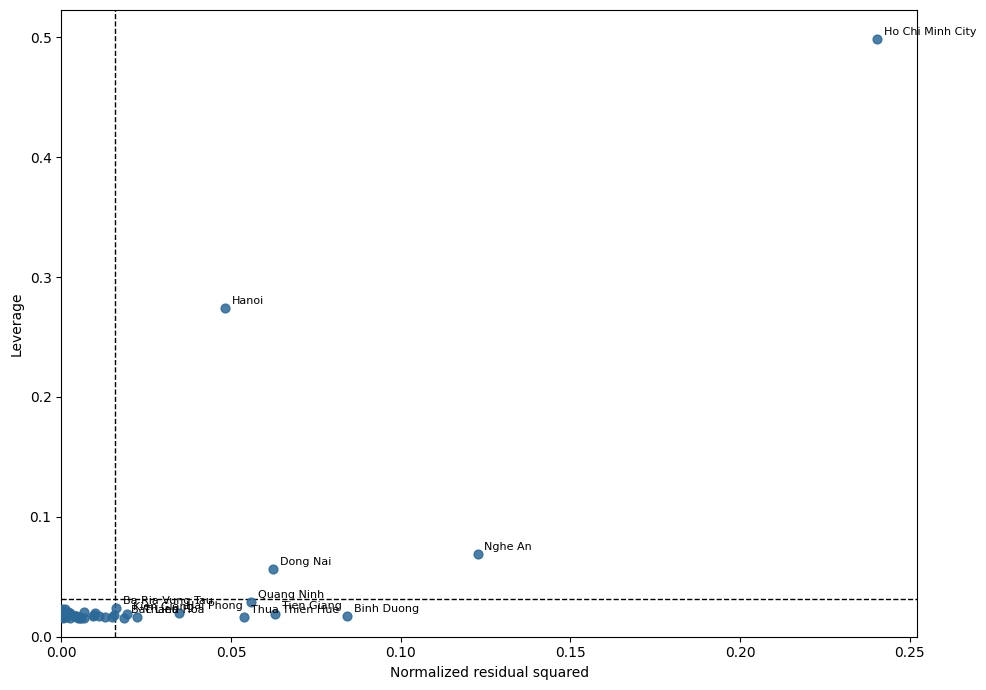

In [104]:
influence = m_acc.get_influence()          # ← m_acc, KHÔNG phải m_acc2
lev       = influence.hat_matrix_diag      # hii

resid_raw     = m_acc.resid
norm_resid_sq = resid_raw**2 / np.sum(resid_raw**2)   # eᵢ²/Σeᵢ²

mean_lev           = lev.mean()
mean_norm_resid_sq = norm_resid_sq.mean()

fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(norm_resid_sq, lev, color=palette[2], alpha=0.85, s=40, zorder=3)

# Label tất cả các điểm nổi bật (cao hơn ngưỡng trung bình)
for i in range(len(df_acc)):
    if lev[i] > mean_lev or norm_resid_sq[i] > mean_norm_resid_sq:
        ax.annotate(df_acc["province_en"].iloc[i],
                    (norm_resid_sq[i], lev[i]),
                    textcoords="offset points", xytext=(5, 3), fontsize=8)

# Hai đường dashed tại giá trị trung bình — đúng như Stata lvr2plot
ax.axhline(mean_lev,           color="black", linestyle="--", linewidth=1)
ax.axvline(mean_norm_resid_sq, color="black", linestyle="--", linewidth=1)

ax.set_xlabel("Normalized residual squared")
ax.set_ylabel("Leverage")
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)

plt.tight_layout()

---
## Xử lý outlier bằng cách giữ lại – Ví dụ 1 (Bảng 4.15–4.16)

### Bước 1 – Đọc lại dữ liệu và tạo biến Battese

In [105]:
df_b, _ = pyreadstat.read_dta(
    "/content/drive/MyDrive/econometrics/rawdata/migration_remittances_16_full.dta",
    encoding="latin1",
)
df_b["agehead2"] = df_b["agehead"] ** 2

# Battese (1997): thay remittances=0 bằng 1, thêm biến giả not_remittances
df_b["remittances_1"]    = df_b["remittances"].replace(0, 1)
df_b["ln_remittances_1"] = np.log(df_b["remittances_1"])
df_b["not_remittances"]  = (df_b["remittances"] == 0).astype(int)
df_b["ln_per_expenditure"] = np.log(df_b["per_expenditure"])

### Bước 2 – Hồi quy Battese (1997) (Bảng 4.16)

In [106]:
xvars_b = ["ln_remittances_1", "not_remittances", "HHsize", "children15",
           "elderly60", "female_ratio", "genderhead", "agehead", "agehead2", "num_eduhead"]

m_battese = sm.OLS(df_b["ln_per_expenditure"],
                   sm.add_constant(df_b[xvars_b])).fit()
print(m_battese.summary())
# N=9,399 | F(10,9388)=391.62 | R²=0.2944

                            OLS Regression Results                            
Dep. Variable:     ln_per_expenditure   R-squared:                       0.294
Model:                            OLS   Adj. R-squared:                  0.294
Method:                 Least Squares   F-statistic:                     391.6
Date:                Wed, 08 Apr 2026   Prob (F-statistic):               0.00
Time:                        10:41:14   Log-Likelihood:                -7289.4
No. Observations:                9399   AIC:                         1.460e+04
Df Residuals:                    9388   BIC:                         1.468e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                8.8372      0.074  

### Bước 3 – Xác định outlier bằng phương pháp IQR

In [107]:
for var in ["remittances", "per_expenditure"]:
    q1, q3 = df_b[var].quantile([0.25, 0.75])
    iqr = q3 - q1
    df_b[f"outlier_{var}"] = (
        (df_b[var] < q1 - 1.5 * iqr) | (df_b[var] > q3 + 1.5 * iqr)
    ).astype(int)
    print(f"outlier_{var}: {df_b[f'outlier_{var}'].sum()} obs")

outlier_remittances: 1331 obs
outlier_per_expenditure: 472 obs


### Bước 4 – Hồi quy với biến giả outlier (Bảng 4.15)

In [108]:
xvars_b2 = xvars_b + ["outlier_per_expenditure", "outlier_remittances"]
m_outlier = sm.OLS(df_b["ln_per_expenditure"],
                   sm.add_constant(df_b[xvars_b2])).fit()
print(m_outlier.summary())
# N=9,399 | F(12,9386)=663.54 | R²=0.4590

                            OLS Regression Results                            
Dep. Variable:     ln_per_expenditure   R-squared:                       0.459
Model:                            OLS   Adj. R-squared:                  0.458
Method:                 Least Squares   F-statistic:                     663.5
Date:                Wed, 08 Apr 2026   Prob (F-statistic):               0.00
Time:                        10:41:14   Log-Likelihood:                -6041.0
No. Observations:                9399   AIC:                         1.211e+04
Df Residuals:                    9386   BIC:                         1.220e+04
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

---
# 4.6 Phân phối xác suất của sai số – Kiểm định Jarque-Bera (JB)

$$
JB = n \left[\frac{S^2}{6} + \frac{(K-3)^2}{24}\right] \sim \chi^2(2)
$$

$S$ = độ lệch (skewness), $K$ = độ nhọn (kurtosis) của phần dư

- $H_0$: phân phối chuẩn
- $\chi^2_{0.05}(2) \approx 5.99$ → bác bỏ $H_0$ khi $JB > 5.99$

## Ví dụ 4 – Mô hình tai nạn giao thông

### Bước 1 – Hồi quy, lấy phần dư và thống kê mô tả

In [109]:
# Dùng lại m_acc (toàn bộ 63 tỉnh)
r_jb4 = m_acc.resid
S4 = skew(r_jb4)
K4 = kurtosis(r_jb4, fisher=False)
n4 = len(r_jb4)
print(f"Obs       = {n4}")
print(f"Mean      = {r_jb4.mean():.2e}")
print(f"Std dev   = {r_jb4.std():.2f}")
print(f"Skewness  = {S4:.4f}")
print(f"Kurtosis  = {K4:.4f}")

Obs       = 63
Mean      = -1.57e-13
Std dev   = 156.11
Skewness  = 0.6520
Kurtosis  = 6.3039


### Bước 2 – Tính thống kê JB thủ công

In [110]:
JB4_manual = n4 * ((S4**2)/6 + ((K4-3)**2)/24)
chi2_crit  = chi2.ppf(0.95, df=2)
print(f"JB (thủ công) = {JB4_manual:.2f}")
print(f"chi2 critical (5%) = {chi2_crit:.4f}")
print("→ Bác bỏ H₀" if JB4_manual > chi2_crit else "→ Không bác bỏ H₀")
# JB ≈ 33.12 > 5.99

JB (thủ công) = 33.12
chi2 critical (5%) = 5.9915
→ Bác bỏ H₀


### Bước 3 – Kiểm định JB tự động

In [111]:
JB4, p_jb4 = jarque_bera(r_jb4)
print(f"Jarque-Bera: {JB4:.2f}  Chi(2)  p = {p_jb4:.2e}")
# JB ≈ 33.12, p = 6.4e-08 → bác bỏ H₀

Jarque-Bera: 33.12  Chi(2)  p = 6.44e-08


## Ví dụ 4 – Sau khi xóa outlier (tỉnh 50)

In [112]:
m_jb4b = sm.OLS(df_acc2["traffic_accidents"],
                sm.add_constant(df_acc2["rotations"])).fit()
print(m_jb4b.summary())
r_jb4b = m_jb4b.resid
JB4b, p_jb4b = jarque_bera(r_jb4b)
print(f"\nJarque-Bera: {JB4b:.2f},  p = {p_jb4b:.2e}")
# JB ≈ 30.29, p = 2.7e-07 → vẫn bác bỏ H₀

                            OLS Regression Results                            
Dep. Variable:      traffic_accidents   R-squared:                       0.363
Model:                            OLS   Adj. R-squared:                  0.352
Method:                 Least Squares   F-statistic:                     34.15
Date:                Wed, 08 Apr 2026   Prob (F-statistic):           2.24e-07
Time:                        10:41:14   Log-Likelihood:                -380.89
No. Observations:                  62   AIC:                             765.8
Df Residuals:                      60   BIC:                             770.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         82.1131     18.848      4.357      0.0

## Ví dụ 1 – Kiểm định JB cho mô hình chi tiêu (Hình 4.3)

### Bước 1 – Hồi quy mô hình với biến giả outlier

In [113]:
# Dùng lại m_outlier đã hồi quy ở phần 4.5
print(m_outlier.summary())

                            OLS Regression Results                            
Dep. Variable:     ln_per_expenditure   R-squared:                       0.459
Model:                            OLS   Adj. R-squared:                  0.458
Method:                 Least Squares   F-statistic:                     663.5
Date:                Wed, 08 Apr 2026   Prob (F-statistic):               0.00
Time:                        10:41:14   Log-Likelihood:                -6041.0
No. Observations:                9399   AIC:                         1.211e+04
Df Residuals:                    9386   BIC:                         1.220e+04
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

### Bước 2 – Thống kê mô tả phần dư

In [114]:
r_jb1 = m_outlier.resid
S1 = skew(r_jb1)
K1 = kurtosis(r_jb1, fisher=False)
n1_jb = len(r_jb1)
JB1 = n1_jb * ((S1**2)/6 + ((K1-3)**2)/24)

print(f"Obs       = {n1_jb}")
print(f"Mean      = {r_jb1.mean():.2e}")
print(f"Std dev   = {r_jb1.std():.4f}")
print(f"Skewness  = {S1:.4f}")
print(f"Kurtosis  = {K1:.4f}")
print(f"JB        = {JB1:.2f}")
# JB ≈ 29.35 > 5.99 → bác bỏ H₀

Obs       = 9399
Mean      = 1.68e-13
Std dev   = 0.4602
Skewness  = -0.1338
Kurtosis  = 3.0580
JB        = 29.35


### Bước 3 – Kiểm định JB tự động và vẽ histogram phần dư (Hình 4.3)

Jarque-Bera: 29.35,  p = 4.23e-07


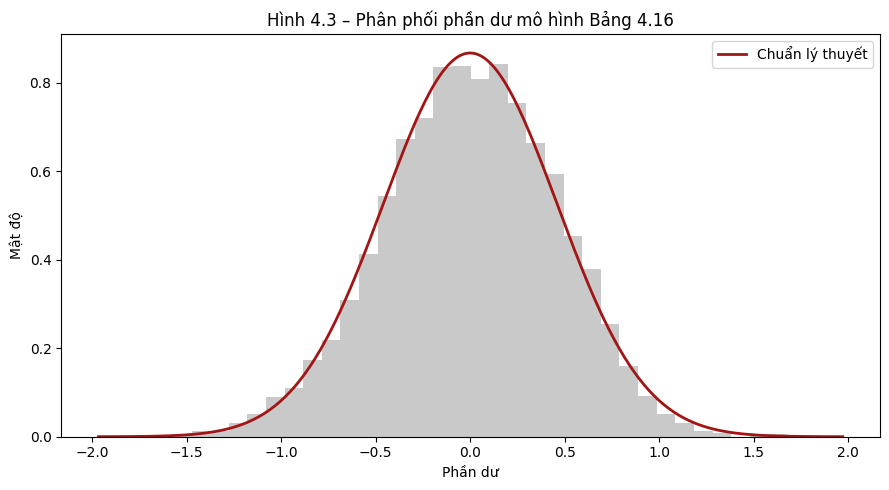

In [115]:
JB1_auto, p_jb1 = jarque_bera(r_jb1)
print(f"Jarque-Bera: {JB1_auto:.2f},  p = {p_jb1:.2e}")

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(r_jb1, bins=40, color=palette[6], alpha=0.7, density=True)
x_fit = np.linspace(r_jb1.min(), r_jb1.max(), 300)
ax.plot(x_fit, norm.pdf(x_fit, r_jb1.mean(), r_jb1.std()),
        color=palette[1], lw=2, label="Chuẩn lý thuyết")
ax.set_xlabel("Phần dư")
ax.set_ylabel("Mật độ")
ax.set_title("Hình 4.3 – Phân phối phần dư mô hình Bảng 4.16")
ax.legend()
plt.tight_layout()


---
# 4.8 Vấn đề tương tác đồng thời (Simultaneity)

Khi biến giải thích **nội sinh** (endogenous) → OLS bị lệch.

## Phương pháp ILS (Indirect Least Squares – Bảng 4.17–4.18)

**Mô hình:** $FCE = \alpha + \beta Y + u$ với $Y = FCE + GCF$ (nội sinh)

**Quy trình ILS:**
1. Rút gọn: hồi quy $FCE \sim GCF$ → lấy $\pi_{11}$
2. Rút gọn: hồi quy $Y \sim GCF$ → lấy $\pi_{21}$
3. Ước lượng: $\hat{\beta} = \pi_{11} / \pi_{21}$

### Bước 1 – Đọc dữ liệu và tạo biến Y

In [116]:
df_gdp, _ = pyreadstat.read_dta(
    "/content/drive/MyDrive/econometrics/rawdata/GCF_FCE.dta",
    encoding="latin1",
)
df_gdp["Y"] = df_gdp["FCE"] + df_gdp["GCF"]
print(df_gdp[["FCE","GCF","Y"]].describe())

              FCE         GCF           Y
count   30.000000   30.000000   30.000000
mean   125.842101   57.228286  183.070386
std     63.641917   36.675607  100.256334
min     46.499771   11.298114   57.797885
25%     67.287111   23.704912   90.992023
50%    113.414860   54.798756  168.213615
75%    175.057461   82.505323  257.562784
max    246.938583  127.442871  374.381454


### Bước 2 – Phương trình rút gọn 1: $FCE \sim GCF$

In [117]:
m_ils1 = sm.OLS(df_gdp["FCE"], sm.add_constant(df_gdp["GCF"])).fit()
print(m_ils1.summary())
pi1_0 = m_ils1.params["const"]
pi1_1 = m_ils1.params["GCF"]
print(f"\nπ₁₀ = {pi1_0:.6f},  π₁₁ = {pi1_1:.6f}")
# F(1,28)=5304.06 | R²=0.9947

                            OLS Regression Results                            
Dep. Variable:                    FCE   R-squared:                       0.995
Model:                            OLS   Adj. R-squared:                  0.995
Method:                 Least Squares   F-statistic:                     5304.
Date:                Wed, 08 Apr 2026   Prob (F-statistic):           1.82e-33
Time:                        10:41:15   Log-Likelihood:                -87.918
No. Observations:                  30   AIC:                             179.8
Df Residuals:                      28   BIC:                             182.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         26.7969      1.607     16.671      0.0

### Bước 3 – Phương trình rút gọn 2: $Y \sim GCF$

In [118]:
m_ils2 = sm.OLS(df_gdp["Y"], sm.add_constant(df_gdp["GCF"])).fit()
print(m_ils2.summary())
pi2_0 = m_ils2.params["const"]
pi2_1 = m_ils2.params["GCF"]
print(f"\nπ₂₀ = {pi2_0:.6f},  π₂₁ = {pi2_1:.6f}")
# F(1,28)=13204.20 | R²=0.9979

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.998
Model:                            OLS   Adj. R-squared:                  0.998
Method:                 Least Squares   F-statistic:                 1.320e+04
Date:                Wed, 08 Apr 2026   Prob (F-statistic):           5.40e-39
Time:                        10:41:15   Log-Likelihood:                -87.918
No. Observations:                  30   AIC:                             179.8
Df Residuals:                      28   BIC:                             182.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         26.7969      1.607     16.671      0.0

### Bước 4 – Tính ước lượng ILS

In [119]:
beta_ILS = pi1_1 / pi2_1
cons_ILS = pi1_0 / pi2_1
print("=== Kết quả ILS (Bảng 4.17) ===")
print(f"β (ILS) = π₁₁ / π₂₁ = {pi1_1:.6f} / {pi2_1:.6f} = {beta_ILS:.6f}")
print(f"α (ILS) = π₁₀ / π₂₁ = {pi1_0:.6f} / {pi2_1:.6f} = {cons_ILS:.6f}")
# β ≈ 0.634, α ≈ 9.813

=== Kết quả ILS (Bảng 4.17) ===
β (ILS) = π₁₁ / π₂₁ = 1.730703 / 2.730703 = 0.633794
α (ILS) = π₁₀ / π₂₁ = 26.796913 / 2.730703 = 9.813191


### Bước 5 – So sánh với OLS trực tiếp (Bảng 4.18)

In [120]:
m_ols_gdp = sm.OLS(df_gdp["FCE"], sm.add_constant(df_gdp["Y"])).fit()
print(m_ols_gdp.summary())
# β OLS ≈ 0.635, α ≈ 9.671
# Gần giống ILS vì mô hình gần như xác định đúng

                            OLS Regression Results                            
Dep. Variable:                    FCE   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 3.982e+04
Date:                Wed, 08 Apr 2026   Prob (F-statistic):           1.07e-45
Time:                        10:41:15   Log-Likelihood:                -57.750
No. Observations:                  30   AIC:                             119.5
Df Residuals:                      28   BIC:                             122.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          9.6713      0.661     14.626      0.0

---
## Phương pháp 2SLS (Two-Stage Least Squares – Bảng 4.21–4.23)

**Bài toán:** `yearsofedu` nội sinh trong phương trình lương

**Biến công cụ:** `fatheredu`, `motheredu`

**Điều kiện biến công cụ hợp lệ:**
- Tương quan với `yearsofedu` (đầy đủ, kiểm tra qua F giai đoạn 1)
- Không tương quan với sai số (đơn giản – kiểm định Sargan)

### Bước 1 – Đọc dữ liệu, tạo biến và thống kê mô tả (Bảng 4.20)

In [121]:
df_wc, _ = pyreadstat.read_dta(
    "/content/drive/MyDrive/econometrics/rawdata/working_children.dta",
    encoding="latin1",
)
df_wc["yearsofexperience2"] = df_wc["yearsofexperience"] ** 2
df_wc["experienceXgender"]  = df_wc["yearsofexperience"] * df_wc["gender"]

controls    = ["urban", "gender", "yearsofexperience", "yearsofexperience2",
               "experienceXgender", "RedRiverDelta", "Northmidlandareas",
               "CentralCoast", "Centralhighlands", "MekongRiverDelta"]
instruments = ["fatheredu", "motheredu"]

print("Thống kê mô tả:")
print(df_wc[["ln_wage","yearsofedu"] + instruments].describe())

Thống kê mô tả:
           ln_wage   yearsofedu    fatheredu    motheredu
count  3611.000000  3611.000000  3611.000000  3611.000000
mean     10.857340     9.235946     7.180559     6.587372
std       0.818964     3.390674     3.648408     3.756552
min       6.396930     0.000000     0.000000     0.000000
25%      10.500948     7.000000     5.000000     4.000000
50%      11.066638    10.000000     8.000000     7.000000
75%      11.392451    12.000000     9.000000     9.000000
max      12.952997    18.000000    21.000000    16.000000


### Bước 2 – Tương quan biến công cụ và biến nội sinh (Bảng 4.20)

In [122]:
print("Tương quan yearsofedu với biến công cụ:")
print(df_wc[["yearsofedu"] + instruments].corr())
# fatheredu: 0.570, motheredu: 0.553 → tương quan đủ mạnh

Tương quan yearsofedu với biến công cụ:
            yearsofedu  fatheredu  motheredu
yearsofedu    1.000000   0.570297   0.553409
fatheredu     0.570297   1.000000   0.678058
motheredu     0.553409   0.678058   1.000000


### Bước 3 – Giai đoạn 1: hồi quy `yearsofedu` (Bảng 4.21)

In [123]:
X_s1 = sm.add_constant(df_wc[instruments + controls])
m_s1 = sm.OLS(df_wc["yearsofedu"], X_s1).fit()
print(m_s1.summary())
# N=3,611 | F(12,3598)=477.84 | R²=0.6145
# fatheredu t=24.17***, motheredu t=17.48*** → biến công cụ mạnh
df_wc["yearsofedu_hat"] = m_s1.fittedvalues

                            OLS Regression Results                            
Dep. Variable:             yearsofedu   R-squared:                       0.614
Model:                            OLS   Adj. R-squared:                  0.613
Method:                 Least Squares   F-statistic:                     477.8
Date:                Wed, 08 Apr 2026   Prob (F-statistic):               0.00
Time:                        10:41:16   Log-Likelihood:                -7811.6
No. Observations:                3611   AIC:                         1.565e+04
Df Residuals:                    3598   BIC:                         1.573e+04
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  7.3156      0

### Bước 4 – Giai đoạn 2: hồi quy `ln_wage` ~ $\hat{edu}$ (Bảng 4.22)

In [124]:
X_s2 = sm.add_constant(df_wc[["yearsofedu_hat"] + controls])
m_s2 = sm.OLS(df_wc["ln_wage"], X_s2).fit()
print(m_s2.summary())
# yearsofedu_hat coef ≈ 0.111
# SE ở giai đoạn 2 thủ công không chính xác → dùng IV2SLS để có SE đúng

                            OLS Regression Results                            
Dep. Variable:                ln_wage   R-squared:                       0.264
Model:                            OLS   Adj. R-squared:                  0.261
Method:                 Least Squares   F-statistic:                     117.2
Date:                Wed, 08 Apr 2026   Prob (F-statistic):          1.20e-229
Time:                        10:41:16   Log-Likelihood:                -3849.4
No. Observations:                3611   AIC:                             7723.
Df Residuals:                    3599   BIC:                             7797.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  9.6873      0

### Bước 5 – 2SLS bằng `IV2SLS` (Bảng 4.23) – SE chính xác

In [125]:
!pip install linearmodels -q
from linearmodels.iv import IV2SLS

m_iv = IV2SLS(
    dependent   = df_wc["ln_wage"],
    exog        = sm.add_constant(df_wc[controls]),
    endog       = df_wc[["yearsofedu"]],
    instruments = df_wc[instruments]
).fit(cov_type="unadjusted")
print(m_iv.summary)
# yearsofedu coef ≈ 0.111, z=15.98***

                          IV-2SLS Estimation Summary                          
Dep. Variable:                ln_wage   R-squared:                      0.2626
Estimator:                    IV-2SLS   Adj. R-squared:                 0.2603
No. Observations:                3611   F-statistic:                    1291.4
Date:                Wed, Apr 08 2026   P-value (F-stat)                0.0000
Time:                        10:41:31   Distribution:                 chi2(11)
Cov. Estimator:            unadjusted                                         
                                                                              
                                 Parameter Estimates                                  
                    Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
--------------------------------------------------------------------------------------
const                  9.6873     0.0868     111.64     0.0000      9.5172      9.8574
urban               

### Bước 6 – Kiểm định biến công cụ

In [126]:
# Kiểm định Sargan (overidentification): H₀ = biến công cụ ngoại sinh
sargan = m_iv.sargan
print("=== Sargan test ===")
print(f"chi2(1) = {sargan.stat:.5f},  p = {sargan.pval:.4f}")
# chi2 ≈ 2.48, p ≈ 0.115 → không bác bỏ H₀ → biến công cụ hợp lệ

# Kiểm định Wu-Hausman (endogeneity): H₀ = yearsofedu ngoại sinh
wu = m_iv.wu_hausman()
print("\n=== Wu-Hausman test ===")
print(f"chi2(1) = {wu.stat:.4f},  p = {wu.pval:.4f}")
# chi2 ≈ 40.75, p = 0.000 → bác bỏ H₀ → yearsofedu nội sinh → 2SLS cần thiết


=== Sargan test ===
chi2(1) = 2.48139,  p = 0.1152

=== Wu-Hausman test ===
chi2(1) = 41.1669,  p = 0.0000


---
### Lưu ý kỹ thuật:
1. **Geometric mean:** tính từ `ln_per_expenditure` trên **toàn bộ** 9,399 obs (kể cả hộ remittances = 0), không lọc trước.
2. **PE test:** mô hình linear dùng 9,399 obs, mô hình log dùng 7,953 obs; giá trị N trong công thức T lấy từ **mô hình log**.
3. **RESET:** Stata dùng `wage_million = wage/1000` để tránh overflow khi tính $\hat{y}^3, \hat{y}^4$.
4. **2SLS:** SE giai đoạn 2 thủ công bị sai; luôn dùng `IV2SLS` hoặc `ivregress` để có SE chính xác.
5. Kết quả số có thể sai lệch nhỏ so với Stata do khác cách triển khai nội bộ giữa các gói thống kê.

<h2 style="font-size: 26px; font-weight: bold; font-family:'Nunito'; color: purple;">About the Authors:</h2>

<a href="https://www.linkedin.com/in/truongnhung2002"> Nhung Truong (Kristen Zhang) </a> has a degree in Investment Economics from UEH, with a focus on quantitative research.

### <h3 align="center"> © 2026 Nhung Truong. Licensed under CC BY 4.0 </h3>